# PROJET REMPLACENT ADRIEN THOMASSON DANS LES BIG 5 LEAGUES

## INGESTION

Importation des bibliothèques et chargement des tables

On charge les fichiers bruts pour vérifier leur structure initiale.

In [278]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import numpy as np



### Problématique n°1 : Comment transformer des extraits de données fragmentés (top100, top200...) en une base de données unique, propre et exploitable pour le scouting ?

In [279]:

# 1. Chargement des 6 tables Ligue 1
df1 = pd.read_csv('./ligue1/top100.csv')
df2 = pd.read_csv('./ligue1/top200.csv')
df3 = pd.read_csv('./ligue1/top300.csv')
df4 = pd.read_csv('./ligue1/top400.csv')
df5 = pd.read_csv('./ligue1/top500.csv')
df6 = pd.read_csv('./ligue1/top600.csv')

# Liste des tables pour la suite
tables_l1 = [df1, df2, df3, df4, df5, df6]
tables_bl = [pd.read_csv('./Bundesliga/top100.csv'), pd.read_csv('./Bundesliga/top200.csv'), pd.read_csv('./Bundesliga/top300.csv'), pd.read_csv('./Bundesliga/top400.csv'), pd.read_csv('./Bundesliga/top500.csv')]
tables_liga = [pd.read_csv('./Laliga/top100.csv'), pd.read_csv('./Laliga/top200.csv'), pd.read_csv('./Laliga/top300.csv'), pd.read_csv('./Laliga/top400.csv'), pd.read_csv('./Laliga/top500.csv'), pd.read_csv('./Laliga/top600.csv')]
tables_PL = [pd.read_csv('./PremierLeague/top100.csv'), pd.read_csv('./PremierLeague/top200.csv'), pd.read_csv('./PremierLeague/top300.csv'), pd.read_csv('./PremierLeague/top400.csv'), pd.read_csv('./PremierLeague/top500.csv'), pd.read_csv('./PremierLeague/top600.csv')]
tables_SA = [pd.read_csv('./SerieA/top100.csv'), pd.read_csv('./SerieA/top200.csv'), pd.read_csv('./SerieA/top300.csv'), pd.read_csv('./SerieA/top400.csv'), pd.read_csv('./SerieA/top500.csv'), pd.read_csv('./SerieA/top600.csv')]

df_gen = pd.read_csv('./stats/general_Stats.csv')

# Affichage rapide pour vérification du format
df1.head(3)

,results__goals,results__expectedGoals,results__assists,results__expectedAssists,results__rating,results__yellowCards,results__redCards,results__minutesPlayed,results__appearances,results__matchesStarted,...,results__team__fieldTranslations__|__ru,results__team__fieldTranslations__nameTranslation__ar,results__team__fieldTranslations__nameTranslation__bn,results__team__fieldTranslations__nameTranslation__hi,results__team__fieldTranslations__nameTranslation__ru,results__team__fieldTranslations__shortNameTranslation__ar,results__team__fieldTranslations__shortNameTranslation__bn,results__team__fieldTranslations__shortNameTranslation__hi,page,pages
0,0.0,NaN,0.0,0.00,7.83,2.0,0.0,315.0,4.0,3.0,...,NaN,لوهافر,লে হাভরে,ले हावरे,Гавр,NaN,NaN,NaN,1.0,6.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,0.83,7.0,3.34,7.68,2.0,0.0,1676.0,22.0,19.0,...,NaN,باريس سان جيرمان,NaN,पेरिस सेंट-जर्मेन,Пари Сен-Жермен,NaN,পিএসজি,पीएसजी,NaN,NaN


On vérifie si un joueur comme Matthis Abline est présent pour s'assurer que les données sont bien chargées.

In [280]:
# Test sur le joueur Matthis Abline sur la premiere table
df1[df1['results__player__name'] == 'Matthis Abline']

,results__goals,results__expectedGoals,results__assists,results__expectedAssists,results__rating,results__yellowCards,results__redCards,results__minutesPlayed,results__appearances,results__matchesStarted,...,results__team__fieldTranslations__|__ru,results__team__fieldTranslations__nameTranslation__ar,results__team__fieldTranslations__nameTranslation__bn,results__team__fieldTranslations__nameTranslation__hi,results__team__fieldTranslations__nameTranslation__ru,results__team__fieldTranslations__shortNameTranslation__ar,results__team__fieldTranslations__shortNameTranslation__bn,results__team__fieldTranslations__shortNameTranslation__hi,page,pages


In [281]:
# Test sur le joueur Matthis Abline sur la deuxieme table
df2[df2['results__player__name'] == 'Matthis Abline']

,results__goals,results__expectedGoals,results__assists,results__expectedAssists,results__rating,results__yellowCards,results__redCards,results__minutesPlayed,results__appearances,results__matchesStarted,...,results__team__fieldTranslations__|__ru,results__team__fieldTranslations__nameTranslation__ar,results__team__fieldTranslations__nameTranslation__bn,results__team__fieldTranslations__nameTranslation__hi,results__team__fieldTranslations__nameTranslation__ru,results__team__fieldTranslations__shortNameTranslation__ar,results__team__fieldTranslations__shortNameTranslation__bn,results__team__fieldTranslations__shortNameTranslation__hi,page,pages
0,4.0,4.56,2.0,2.07,6.95,5.0,0.0,1784.0,22.0,19.0,...,NaN,نانت,ন্যান্টেস,नांत,Нант,NaN,NaN,NaN,2.0,6.0


## Data Cleaning

### On fusionne les 6 tables et on nettoie les colonnes pour enlever le préfixe 'results__'.

In [282]:
# Concaténation
df_ligue1 = pd.concat(tables_l1, ignore_index=True)

# Nettoyage des noms de colonnes (très important pour la lisibilité)
df_ligue1.columns = [c.replace('results__', '') for c in df_ligue1.columns]

# Suppression des lignes sans nom de joueur (nettoyage SofaScore)
df_ligue1 = df_ligue1.dropna(subset=['player__name'])

print(f"Table Ligue 1 créée. Nombre de joueurs : {len(df_ligue1)}")
df_ligue1.head(5)

Table Ligue 1 créée. Nombre de joueurs : 517


,goals,expectedGoals,assists,expectedAssists,rating,yellowCards,redCards,minutesPlayed,appearances,matchesStarted,...,team__fieldTranslations__nameTranslation__ru,team__fieldTranslations__shortNameTranslation__ar,team__fieldTranslations__shortNameTranslation__bn,team__fieldTranslations__shortNameTranslation__hi,page,pages,player__fieldTranslations__nameTranslation__ar,player__fieldTranslations__shortNameTranslation__ar,player__fieldTranslations__shortNameTranslation__bn,player__fieldTranslations__shortNameTranslation__hi
0,0.0,NaN,0.0,0.00,7.83,2.0,0.0,315.0,4.0,3.0,...,Гавр,NaN,NaN,NaN,1.0,6.0,NaN,NaN,NaN,NaN
2,1.0,0.83,7.0,3.34,7.68,2.0,0.0,1676.0,22.0,19.0,...,Пари Сен-Жермен,NaN,পিএসজি,पीएसजी,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0,0.15,2.0,0.81,7.53,0.0,0.0,105.0,3.0,0.0,...,Страсбур,ستراسبورغ,স্ট্রাসবার্গ,स्ट्रासबर्ग,NaN,NaN,NaN,NaN,NaN,NaN
6,8.0,4.58,4.0,3.45,7.53,0.0,0.0,688.0,14.0,7.0,...,Пари Сен-Жермен,NaN,পিএসজি,पीएसजी,NaN,NaN,NaN,NaN,NaN,NaN
8,8.0,5.59,4.0,4.68,7.53,5.0,0.0,1897.0,22.0,22.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


On s'assure que Thomasson est bien présent dans la table finale avec toutes ses stats

In [283]:
# Isolation de notre base de comparaison
df_ligue1[df_ligue1['player__name'].str.contains('Thomasson', na=False)]

,goals,expectedGoals,assists,expectedAssists,rating,yellowCards,redCards,minutesPlayed,appearances,matchesStarted,...,team__fieldTranslations__nameTranslation__ru,team__fieldTranslations__shortNameTranslation__ar,team__fieldTranslations__shortNameTranslation__bn,team__fieldTranslations__shortNameTranslation__hi,page,pages,player__fieldTranslations__nameTranslation__ar,player__fieldTranslations__shortNameTranslation__ar,player__fieldTranslations__shortNameTranslation__bn,player__fieldTranslations__shortNameTranslation__hi
278,2.0,4.64,6.0,4.05,6.88,7.0,0.0,1922.0,22.0,22.0,...,Ланс,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Maintenant je fais la meme manip pour avoir une table des stats des joueurs de chaque chompionnat du BIG 5

### Bundesliga

In [284]:
df_bl = pd.concat(tables_bl, ignore_index=True)

# Nettoyage des noms de colonnes (très important pour la lisibilité)
df_bl.columns = [c.replace('results__', '') for c in df_bl.columns]

# Suppression des lignes sans nom de joueur (nettoyage SofaScore)
df_bl = df_bl.dropna(subset=['player__name'])

print(f"Table Bundesliga créée. Nombre de joueurs : {len(df_bl)}")
df_bl.head(5)
# Isolation de notre base de comparaison
df_ligue1[df_ligue1['player__name'].str.contains('Wind', na=False)]

Table Bundesliga créée. Nombre de joueurs : 392


,goals,expectedGoals,assists,expectedAssists,rating,yellowCards,redCards,minutesPlayed,appearances,matchesStarted,...,team__fieldTranslations__nameTranslation__ru,team__fieldTranslations__shortNameTranslation__ar,team__fieldTranslations__shortNameTranslation__bn,team__fieldTranslations__shortNameTranslation__hi,page,pages,player__fieldTranslations__nameTranslation__ar,player__fieldTranslations__shortNameTranslation__ar,player__fieldTranslations__shortNameTranslation__bn,player__fieldTranslations__shortNameTranslation__hi


### La liga

In [285]:
df_liga = pd.concat(tables_liga, ignore_index=True)

# Nettoyage des noms de colonnes (très important pour la lisibilité)
df_liga.columns = [c.replace('results__', '') for c in df_liga.columns]
# Suppression des lignes sans nom de joueur (nettoyage SofaScore)
df_liga = df_liga.dropna(subset=['player__name'])

print(f"Table Liga créée. Nombre de joueurs : {len(df_liga)}")
df_liga.head(5)
# Isolation de notre base de comparaison
df_liga[df_liga['player__name'].str.contains('Yago Santiago', na=False)]


Table Liga créée. Nombre de joueurs : 553


,goals,expectedGoals,assists,expectedAssists,rating,yellowCards,redCards,minutesPlayed,appearances,matchesStarted,...,team__fieldTranslations__|__ru,team__fieldTranslations__nameTranslation__ar,team__fieldTranslations__nameTranslation__bn,team__fieldTranslations__nameTranslation__hi,team__fieldTranslations__nameTranslation__ru,team__fieldTranslations__shortNameTranslation__ar,team__fieldTranslations__shortNameTranslation__bn,team__fieldTranslations__shortNameTranslation__hi,page,pages
997,0.0,0.12,0.0,0.21,6.45,1.0,1.0,277.0,8.0,3.0,...,NaN,إلتشي,এলচে,एल्चे,Эльче,NaN,NaN,NaN,NaN,NaN


### Premier League

In [286]:
df_PL = pd.concat(tables_PL, ignore_index=True)

# Nettoyage des noms de colonnes (très important pour la lisibilité)
df_PL.columns = [c.replace('results__', '') for c in df_PL.columns]
# Suppression des lignes sans nom de joueur (nettoyage SofaScore)
df_PL = df_PL.dropna(subset=['player__name'])

print(f"Table Premier League créée. Nombre de joueurs : {len(df_PL)}")
df_PL.head(5)

Table Premier League créée. Nombre de joueurs : 515


,goals,expectedGoals,assists,expectedAssists,rating,yellowCards,redCards,minutesPlayed,appearances,matchesStarted,...,team__fieldTranslations__nameTranslation__ru,team__fieldTranslations__shortNameTranslation__ar,team__fieldTranslations__shortNameTranslation__bn,team__fieldTranslations__shortNameTranslation__hi,page,pages,player__fieldTranslations__nameTranslation__ar,player__fieldTranslations__shortNameTranslation__ar,player__fieldTranslations__shortNameTranslation__bn,player__fieldTranslations__shortNameTranslation__hi
0,1.0,0.16,0.0,0.00,7.60,0.0,0.0,15.0,1.0,0.0,...,Вулверхэмптон Уондерерс,وولفز,উলভস,वॉल्व्स,1.0,6.0,NaN,NaN,NaN,NaN
2,6.0,8.18,12.0,6.73,7.53,3.0,0.0,2077.0,24.0,24.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9.0,4.82,4.0,3.65,7.49,5.0,0.0,2018.0,23.0,22.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,4.0,2.77,4.0,5.63,7.48,2.0,0.0,2329.0,27.0,26.0,...,Арсенал,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,22.0,20.60,7.0,2.01,7.43,1.0,0.0,2238.0,27.0,26.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Serie A

In [287]:
df_SA = pd.concat(tables_SA, ignore_index=True)

# Nettoyage des noms de colonnes (très important pour la lisibilité)
df_SA.columns = [c.replace('results__', '') for c in df_SA.columns]
# Suppression des lignes sans nom de joueur (nettoyage SofaScore)
df_SA = df_SA.dropna(subset=['player__name'])

print(f"Table Serie A créée. Nombre de joueurs : {len(df_SA)}")
df_SA.head(5)

Table Serie A créée. Nombre de joueurs : 550

,goals,expectedGoals,assists,expectedAssists,rating,yellowCards,redCards,minutesPlayed,appearances,matchesStarted,...,team__fieldTranslations__|__bn,team__fieldTranslations__|__hi,team__fieldTranslations__|__ru,team__fieldTranslations__nameTranslation__ar,team__fieldTranslations__nameTranslation__bn,team__fieldTranslations__nameTranslation__hi,team__fieldTranslations__nameTranslation__ru,team__fieldTranslations__shortNameTranslation__ar,page,pages
0,1.0,0.38,0.0,0.04,7.80,0.0,0.0,105.0,2.0,1.0,...,NaN,NaN,NaN,نابولي,নাপোলি,नेपोली,Наполи,NaN,1.0,6.0
2,1.0,1.19,1.0,2.63,7.62,5.0,0.0,2014.0,25.0,25.0,...,NaN,NaN,NaN,يوفنتوس,জুভেন্টাস,जुवेंटस,Ювентус,NaN,NaN,NaN
4,0.0,NaN,0.0,0.00,7.60,1.0,0.0,90.0,1.0,1.0,...,NaN,NaN,NaN,بارما,পরমা,पर्मा,Парма Кальчо,NaN,NaN,NaN
6,2.0,1.25,3.0,3.85,7.56,3.0,0.0,2101.0,25.0,24.0,...,NaN,NaN,NaN,ميلان,মিলান,मिलान,Милан,NaN,NaN,NaN
8,5.0,3.77,13.0,7.73,7.55,2.0,0.0,1897.0,24.0,20.0,...,NaN,NaN,NaN,انتر,ইন্টার,इंटर,Интер,NaN,NaN,NaN


Problématique : Comment créer un marché européen unique pour le recrutement ? Nous ajoutons une colonne 'League' pour garder la traçabilité avant de fusionner les données.

In [288]:
# Avant de concaténer, on marque l'origine de chaque donnée
df_ligue1['league_name'] = 'Ligue 1'
df_PL['league_name'] = 'Premier League'
df_bl['league_name'] = 'Bundesliga'
df_liga['league_name'] = 'La Liga'
df_SA['league_name'] = 'Serie A'

# Création du Master Dataset
df_big5 = pd.concat([df_ligue1, df_PL, df_bl, df_liga, df_SA], ignore_index=True)

print(f"Master Dataset 'df_big5' créé. Nombre total de profils : {len(df_big5)}")

Master Dataset 'df_big5' créé. Nombre total de profils : 2527


In [289]:
# On prend Joueur, Position, Nation, Age
df_pos = df_gen[['1_level_0_Player', '3_level_0_Pos', '2_level_0_Nation', '6_level_0_Age']].copy()
df_pos.columns = ['player__name', 'player_position', 'player_nation', 'player_age']

# Nettoyage : FBref met souvent "fr FRA" pour la nation et "28-150" pour l'âge
df_pos['player_nation'] = df_pos['player_nation'].str.split(' ').str[-1] # Garde juste "FRA"
df_pos['player_age'] = df_pos['player_age'].astype(str).str.split('-').str[0]       # Garde juste "28"

# 3. Supprimer les doublons dans FBref
cols_to_drop = ['player_position', 'player_nation', 'player_age']
for col in cols_to_drop:
    if col in df_big5.columns:
        df_big5 = df_big5.drop(columns=[col])

# 4. Fusion propre (Merge)
df_big5 = pd.merge(df_big5, df_pos, on='player__name', how='left')

# 5. Remplacement des vides (Fillna)
# Maintenant les colonnes existent à coup sûr et n'ont pas de suffixe _x ou _y
df_big5['player_position'] = df_big5['player_position'].fillna('Unknown')
df_big5['player_nation'] = df_big5['player_nation'].fillna('Unknown')
df_big5['player_age'] = pd.to_numeric(df_big5['player_age'], errors='coerce')

print(f"✅ Données démographiques intégrées. Total joueurs : {len(df_big5)}")
df_big5[['player__name', 'player_position', 'player_nation', 'player_age']].head(10)

✅ Données démographiques intégrées. Total joueurs : 2730


,player__name,player_position,player_nation,player_age
0,Lionel M'Pasi,Unknown,Unknown,NaN
1,Vitinha,"FW,MF",POR,25.0
2,Vitinha,MF,POR,26.0
3,Dilane Bakwa,MF,FRA,23.0
4,Dilane Bakwa,"FW,MF",FRA,23.0
5,Ousmane Dembélé,FW,FRA,28.0
6,Ilan Kebbal,"MF,FW",ALG,27.0
7,Mason Greenwood,MF,ENG,24.0
8,Rémy Descamps,GK,FRA,29.0
9,Aron Dønnum,"MF,FW",NOR,27.0


j'avais dans player_position 1403 non nulle ce qui veut dire il reste 1600-1403 = 197 joeuers qui la valeur Nan donc j'ai changer cette valeur en Unknown pour eviter les problemes a venir

In [290]:
thomasson_pos = df_big5[df_big5['player__name'].str.contains('Thomasson', na=False)]
print(f"Position détectée pour Thomasson : {thomasson_pos['player_position'].iloc[0]}")


df_big5['player_position'] = df_big5['player_position'].fillna('Unknown') 
df_big5

Position détectée pour Thomasson : MF


,goals,expectedGoals,assists,expectedAssists,rating,yellowCards,redCards,minutesPlayed,appearances,matchesStarted,...,page,pages,player__fieldTranslations__nameTranslation__ar,player__fieldTranslations__shortNameTranslation__ar,player__fieldTranslations__shortNameTranslation__bn,player__fieldTranslations__shortNameTranslation__hi,league_name,player_position,player_nation,player_age
0,0.0,NaN,0.0,0.00,7.83,2.0,0.0,315.0,4.0,3.0,...,1.0,6.0,NaN,NaN,NaN,NaN,Ligue 1,Unknown,Unknown,NaN
1,1.0,0.83,7.0,3.34,7.68,2.0,0.0,1676.0,22.0,19.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Ligue 1,"FW,MF",POR,25.0
2,1.0,0.83,7.0,3.34,7.68,2.0,0.0,1676.0,22.0,19.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Ligue 1,MF,POR,26.0
3,1.0,0.15,2.0,0.81,7.53,0.0,0.0,105.0,3.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Ligue 1,MF,FRA,23.0
4,1.0,0.15,2.0,0.81,7.53,0.0,0.0,105.0,3.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Ligue 1,"FW,MF",FRA,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2725,0.0,NaN,0.0,NaN,0.00,0.0,0.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Serie A,MF,SVN,22.0
2726,0.0,NaN,0.0,0.00,0.00,0.0,0.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Serie A,Unknown,Unknown,NaN
2727,0.0,NaN,0.0,NaN,0.00,0.0,0.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Serie A,Unknown,Unknown,NaN
2728,0.0,NaN,0.0,0.00,0.00,0.0,0.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Serie A,DF,NED,25.0


## Problématique : Comment transformer un dataset "pollué" par des données de traduction en une matrice de scouting pure ? Nous allons filtrer les colonnes pour ne garder que l'identité du joueur et ses KPIs de performance.

Comment créer un marché unique ? Nous devons réunir les 5 ligues dans une seule matrice tout en gardant une trace de l'origine pour l'analyse de marché.

In [291]:

# Sélection des 22 colonnes (en enlevant les traductions)
cols_identite = ['player__name', 'player_age', 'player_position', 'player_nation', 'team__name', 'league_name', 'minutesPlayed', 'rating',]
cols_performance = [
    'goals', 'expectedGoals', 'assists', 'expectedAssists', 
    'tackles', 'interceptions', 'fouls', 'blockedShots', 'dribbledPast', 'clearances',
    'groundDuelsWon', 'groundDuelsWonPercentage', 'aerialDuelsWon', 'aerialDuelsWonPercentage',
    'accuratePassesPercentage', 'accurateFinalThirdPasses', 'keyPasses'
]

df_big5 = df_big5[cols_identite + cols_performance].copy()
df_big5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2730 entries, 0 to 2729
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player__name              2730 non-null   object 
 1   player_age                2378 non-null   float64
 2   player_position           2730 non-null   object 
 3   player_nation             2730 non-null   object 
 4   team__name                2730 non-null   object 
 5   league_name               2730 non-null   object 
 6   minutesPlayed             2709 non-null   float64
 7   rating                    2730 non-null   float64
 8   goals                     2730 non-null   float64
 9   expectedGoals             2274 non-null   float64
 10  assists                   2730 non-null   float64
 11  expectedAssists           2680 non-null   float64
 12  tackles                   2730 non-null   float64
 13  interceptions             2709 non-null   float64
 14  fouls   

## Problématique : Comment garantir que les joueurs identifiés ont un échantillon de données suffisant pour être comparés à Thomasson ? Un joueur ayant réussi 2 tacles en 10 minutes afficherait un taux de 18 tacles/90min, ce qui est une aberration statistique.

Je décide de lier le seuil de sélection au temps de jeu d'Adrien Thomasson. Nous retiendrons les joueurs ayant joué au moins 25% du temps de jeu de notre référence, ce qui assure une base de comparaison solide d'au moins 5 à 6 matchs.

In [292]:
# 1. Récupérer le temps de jeu de référence
thomasson_mins = df_ligue1[df_ligue1['player__name'].str.contains('Thomasson', na=False)]['minutesPlayed'].iloc[0]

# 2. Définir le seuil dynamique (25% du temps de jeu de la référence)
seuil_min = thomasson_mins * 0.25

print(f"Temps de jeu Thomasson : {thomasson_mins} min")
print(f"Seuil de fiabilité retenu : {seuil_min:.0f} min (25%)")

# 3. Application du filtre sur chaque championnat (ou sur la table globale si tu as fusionné)
df_L1_clean = df_ligue1[df_ligue1['minutesPlayed'] >= seuil_min].copy()

# Vérification du nombre de joueurs restants
print(f"Nombre de joueurs conservés en Ligue 1 : {len(df_L1_clean)}")

Temps de jeu Thomasson : 1922.0 min
Seuil de fiabilité retenu : 480 min (25%)
Nombre de joueurs conservés en Ligue 1 : 309


### Suppression des doublons (Sécurité contre les chevauchements de fichiers topX)

In [293]:

df_big5 = df_big5.drop_duplicates(subset=['player__name', 'team__name'], keep='first')
df_big5.shape

(2527, 25)

### Regler le probleme de Nan Pour que ne produise pas un erreur si on veut faire une comparaison remplace nan par 0

In [294]:
#Gestion des NaNs
# Pour les stats de performance, on remplace par 0
df_big5[cols_performance] = df_big5[cols_performance].fillna(0)
df_big5['expectedGoals']

0       0.00
1       0.83
3       0.15
5       4.58
6       5.59
        ... 
2725    0.00
2726    0.00
2727    0.00
2728    0.00
2729    0.00
Name: expectedGoals, Length: 2527, dtype: float64

### Application du Filtre de Fiabilité

In [295]:
# On utilise le seuil de 480 minutes que nous avons défini ensemble
min_minutes_required = 480
df_big5_clean = df_big5[df_big5['minutesPlayed'] >= min_minutes_required].copy()

### Pour les minutes, on supprime les joueurs sans temps de jeu (impossible de calculer le p90 sinon)

In [296]:
df_big5 = df_big5.dropna(subset=['minutesPlayed'])
check_thomasson = df_big5_clean[df_big5_clean['player__name'].str.contains('Thomasson', na=False)]
print(f"Joueurs initiaux : {len(df_big5)}")
print(f"Joueurs après de-duplication et filtrage (> {min_minutes_required} min) : {len(df_big5_clean)}")

if not check_thomasson.empty:
    print(f" Adrien Thomasson est bien présent dans la base finale.")
else:
    print(f" ATTENTION : Adrien Thomasson a disparu ! Vérifie les filtres.")
    
df_big5_clean

Joueurs initiaux : 2507
Joueurs après de-duplication et filtrage (> 480 min) : 1600
 Adrien Thomasson est bien présent dans la base finale.


,player__name,player_age,player_position,player_nation,team__name,league_name,minutesPlayed,rating,goals,expectedGoals,...,blockedShots,dribbledPast,clearances,groundDuelsWon,groundDuelsWonPercentage,aerialDuelsWon,aerialDuelsWonPercentage,accuratePassesPercentage,accurateFinalThirdPasses,keyPasses
1,Vitinha,25.0,"FW,MF",POR,Paris Saint-Germain,Ligue 1,1676.0,7.68,1.0,0.83,...,8.0,13.0,20.0,45.0,58.44,2.0,50.00,94.02,528.0,29.0
5,Ousmane Dembélé,28.0,FW,FRA,Paris Saint-Germain,Ligue 1,688.0,7.53,8.0,4.58,...,3.0,1.0,0.0,22.0,47.83,2.0,33.33,84.54,249.0,32.0
6,Ilan Kebbal,27.0,"MF,FW",ALG,Paris FC,Ligue 1,1897.0,7.53,8.0,5.59,...,9.0,12.0,6.0,108.0,54.00,2.0,16.67,86.29,335.0,46.0
7,Mason Greenwood,24.0,MF,ENG,Olympique de Marseille,Ligue 1,1741.0,7.43,14.0,11.54,...,22.0,16.0,2.0,64.0,43.84,2.0,28.57,82.01,318.0,42.0
9,Aron Dønnum,27.0,"MF,FW",NOR,Toulouse,Ligue 1,1681.0,7.35,3.0,4.22,...,7.0,17.0,11.0,82.0,47.40,3.0,75.00,78.77,196.0,43.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2689,Henrik Wendel Meister,NaN,Unknown,Unknown,Pisa,Serie A,1276.0,6.43,2.0,3.42,...,3.0,3.0,6.0,27.0,31.03,30.0,41.10,60.83,30.0,3.0
2691,Jonathan David,26.0,FW,CAN,Juventus,Serie A,1319.0,6.43,5.0,7.72,...,9.0,7.0,3.0,35.0,39.33,10.0,26.32,79.45,144.0,27.0
2695,Santiago Pierotti,24.0,"MF,FW",ARG,Lecce,Serie A,1635.0,6.41,0.0,1.79,...,9.0,24.0,15.0,85.0,35.71,29.0,36.25,75.49,101.0,12.0
2703,Abdoulaye Ndiaye,NaN,Unknown,Unknown,Parma,Serie A,496.0,6.37,0.0,0.29,...,0.0,6.0,28.0,20.0,55.56,20.0,60.61,82.07,15.0,1.0


In [297]:

df_big5_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1600 entries, 1 to 2704
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player__name              1600 non-null   object 
 1   player_age                1403 non-null   float64
 2   player_position           1600 non-null   object 
 3   player_nation             1600 non-null   object 
 4   team__name                1600 non-null   object 
 5   league_name               1600 non-null   object 
 6   minutesPlayed             1600 non-null   float64
 7   rating                    1600 non-null   float64
 8   goals                     1600 non-null   float64
 9   expectedGoals             1600 non-null   float64
 10  assists                   1600 non-null   float64
 11  expectedAssists           1600 non-null   float64
 12  tackles                   1600 non-null   float64
 13  interceptions             1600 non-null   float64
 14  fouls        

## Normalisation

 ### Problematique : Comment comparer équitablement un titulaire indiscutable et un remplaçant efficace ? Pour trouver le "clone" de Thomasson, nous devons ramener toutes les données sur une base commune de 90 minutes. Nous allons aussi créer le Pressing Index, qui est la signature tactique recherchée pour remplacer Adrien.

In [298]:
# 1. On travaille sur ta table propre (déjà filtrée > 480 min)
df_final = df_big5_clean.copy()

# 2. Calcul du nombre de "matchs de 90 minutes" joués
# C'est la base de calcul pour toutes les stats de volume
df_final['90s'] = df_final['minutesPlayed'] / 90

# 3. Liste des colonnes de volume à normaliser (celles de ton info())
cols_to_normalize = [
    'goals', 'expectedGoals', 'assists', 'expectedAssists', 
    'tackles', 'interceptions', 'fouls', 'blockedShots', 
    'clearances', 'groundDuelsWon', 'keyPasses', 'accurateFinalThirdPasses', 'aerialDuelsWon'
]

# Calcul automatique des colonnes _p90
for col in cols_to_normalize:
    df_final[f'{col}_p90'] = df_final[col] / df_final['90s']

# 4. Création du Pressing Index (La "Signature Thomasson")
# On combine les actions défensives actives ramenées aux 90 minutes
df_final['pressing_index'] = (
    df_final['tackles_p90'] + 
    df_final['interceptions_p90'] + 
    (df_final['fouls'] / df_final['90s']) # On normalise les fautes aussi
)

# 5. Vérification du résultat sur notre étalon Adrien Thomasson
thomasson_check = df_final[df_final['player__name'].str.contains('Thomasson', na=False)]

print(f"✅ Normalisation terminée sur {len(df_final)} joueurs.")
print("---")
print("Aperçu des stats normalisées pour Thomasson :")
thomasson_check[['player__name', 'tackles_p90', 'interceptions_p90', 'pressing_index', 'accurateFinalThirdPasses_p90']]

✅ Normalisation terminée sur 1600 joueurs.
---
Aperçu des stats normalisées pour Thomasson :


,player__name,tackles_p90,interceptions_p90,pressing_index,accurateFinalThirdPasses_p90
150,Adrien Thomasson,2.950052,0.655567,5.665973,10.301769


### Problématique : Un score de 5.7 en pressing est-il performant ? Pour comparer des statistiques de natures différentes (buts vs tacles), nous convertissons chaque performance en percentile (de 0 à 100). Cela permet de situer chaque joueur par rapport à la moyenne du Big 5.

In [299]:
# 1. Sélection des colonnes clés pour le "Thomasson Engine"
# On choisit les stats qui définissent son profil de "Pressing Playmaker"
cols_scouting = [
    'rating', 'pressing_index', 'accurateFinalThirdPasses_p90', 
    'keyPasses_p90', 'expectedGoals_p90', 'goals_p90', 'expectedAssists_p90',
    'groundDuelsWonPercentage', 'tackles_p90', 'interceptions_p90',
    'aerialDuelsWon_p90', 'aerialDuelsWonPercentage'
]

# 2. Calcul des Percentiles
# On transforme chaque valeur en son rang relatif (0 à 100)
for col in cols_scouting:
    df_final[f'{col}_pct'] = df_final[col].rank(pct=True) * 100

# 3. Vérification pour Thomasson
thomasson_pct = df_final[df_final['player__name'].str.contains('Thomasson', na=False)]

print("✅ Conversion en Percentiles terminée.")
print("Voici le profil 'relatif' de Thomasson (Top % d'Europe) :")
thomasson_pct[[f'{c}_pct' for c in cols_scouting]].round(1)

✅ Conversion en Percentiles terminée.
Voici le profil 'relatif' de Thomasson (Top % d'Europe) :


,rating_pct,pressing_index_pct,accurateFinalThirdPasses_p90_pct,keyPasses_p90_pct,expectedGoals_p90_pct,goals_p90_pct,expectedAssists_p90_pct,groundDuelsWonPercentage_pct,tackles_p90_pct,interceptions_p90_pct,aerialDuelsWon_p90_pct,aerialDuelsWonPercentage_pct
150,68.1,94.2,76.9,98.1,79.4,57.1,90.4,25.7,95.0,46.2,27.5,30.0


Analyse : Cela confirme scientifiquement le profil de Thomasson. Il est excellent pour se projeter et se retrouver dans des situations de tir (xG élevé), mais il est moins "tueur" ou "clinique" dans la finition que des attaquants de métier. C'est exactement ce que l'on attend d'un milieu box-to-box qui travaille énormément.

#### 1. Calcul du Score de Playmaking (La Vision & Création)

In [300]:

# On mélange la progression (Final Third) et la création pure (Key Passes / xA)
df_final['playmaking_score'] = (
    df_final['accurateFinalThirdPasses_p90_pct'] + 
    df_final['keyPasses_p90_pct'] + 
    df_final['expectedAssists_p90_pct']
) / 3


#### Calcul du Score de Résilience (Duels)

In [301]:


# On mélange l'efficacité au sol et dans les airs
df_final['resilience_score'] = (
    df_final['groundDuelsWonPercentage_pct'] + 
    df_final['aerialDuelsWonPercentage_pct']
) / 2


#### Calcul du Score de Menace Individuelle (Attaque)

In [302]:


# On regarde la capacité à se retrouver en position de tir (xG) et la finition (Goals)
df_final['threat_score'] = (
    df_final['expectedGoals_p90_pct'] + 
    df_final['goals_p90_pct']
) / 2


#### On garde le Pressing Index qu'on a déjà calculé, mais on le met sur 100 aussi pour l'équilibre


In [303]:

df_final['pressing_score'] = df_final['pressing_index'].rank(pct=True) * 100

# --- VÉRIFICATION DU PROFIL COMPLET DE THOMASSON ---
thomasson_final_profile = df_final[df_final['player__name'].str.contains('Thomasson', na=False)]

print("✅ Familles de métriques créées avec succès.")
print("Voici le 'Code Tactique' d'Adrien Thomasson (Notes sur 100) :")
thomasson_final_profile[['player__name', 'pressing_score', 'playmaking_score', 'resilience_score', 'threat_score']].round(1)

✅ Familles de métriques créées avec succès.
Voici le 'Code Tactique' d'Adrien Thomasson (Notes sur 100) :


,player__name,pressing_score,playmaking_score,resilience_score,threat_score
150,Adrien Thomasson,94.2,88.5,27.8,68.2


## Le Moteur de Similarité

### Problématique : Comment identifier mathématiquement les joueurs ayant le profil le plus proche de Thomasson ? Nous utilisons la Similarité Cosinus sur nos 4 piliers tactiques (ADN) pour obtenir un score de ressemblance de 0 à 100%.

In [304]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. On définit les caractéristiques qui forment l'ADN du joueur
features_dna = ['pressing_score', 'playmaking_score', 'resilience_score', 'threat_score']

# 2. On extrait les valeurs de Thomasson pour servir de référence (le "Vecteur Cible")
thomasson_vector = df_final[df_final['player__name'].str.contains('Thomasson', na=False)][features_dna].values

# 3. Calcul de la similarité entre Thomasson et TOUS les joueurs de la base
# Cela crée une liste de scores entre 0 et 1
similarity_array = cosine_similarity(df_final[features_dna], thomasson_vector)

# 4. On ajoute ce score à notre table et on le transforme en pourcentage (0-100%)
df_final['similarity_score'] = similarity_array * 100

# 5. On trie par score pour voir qui arrive en tête (on exclut Thomasson de la liste)
top_clones = df_final[~df_final['player__name'].str.contains('Thomasson', na=False)].sort_values(by='similarity_score', ascending=False)

print("✅ Moteur de similarité activé.")
print(f"Comparaison effectuée sur {len(df_final)} joueurs.")
print("---")
print("Top 50 des profils les plus proches (tous postes confondus) :")
top_clones[['player__name', 'team__name', 'league_name', 'similarity_score']].head(50).round(2)

✅ Moteur de similarité activé.
Comparaison effectuée sur 1600 joueurs.
---
Top 50 des profils les plus proches (tous postes confondus) :


,player__name,team__name,league_name,similarity_score
2661,Amin Sarr,Hellas Verona,Serie A,99.90
2382,Franco Vázquez,Cremonese,Serie A,99.74
232,Samuel Amo-Ameyaw,RC Strasbourg,Ligue 1,99.74
2238,Antonio Vergara,Napoli,Serie A,99.63
1684,Rubén García,Osasuna,La Liga,99.62
1259,Bakery Jatta,Hamburger SV,Bundesliga,99.59
1487,William Mikelbrencis,Hamburger SV,Bundesliga,99.59
97,Kévin Danois,Auxerre,Ligue 1,99.57
2592,Alessio Zerbin,Cremonese,Serie A,99.57
1973,Rodrigo Mendoza,Atlético Madrid,La Liga,99.57


Analyse : en utilisant la similiraty score j'ai pu detecter les joueurs qui se ressemble a thomasson si on groupe les 4 piliers ou metique qu'on a calculer avant

### 

check l'ensemble des positions que j'ai dans mon player_position

In [305]:
positions_uniques = (
    df_big5_clean["player_position"]
    .str.split(",")      # sépare "MF,FW" → ["MF", "FW"]
    .explode()           # met chaque position sur une ligne
    .str.strip()         # enlève les espaces éventuels
    .unique()            # récupère les valeurs uniques
)

print(sorted(positions_uniques))
print("Nombre total :", len(positions_uniques))

['DF', 'FW', 'GK', 'MF', 'Unknown']
Nombre total : 5


In [306]:
df_big5_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1600 entries, 1 to 2704
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player__name              1600 non-null   object 
 1   player_age                1403 non-null   float64
 2   player_position           1600 non-null   object 
 3   player_nation             1600 non-null   object 
 4   team__name                1600 non-null   object 
 5   league_name               1600 non-null   object 
 6   minutesPlayed             1600 non-null   float64
 7   rating                    1600 non-null   float64
 8   goals                     1600 non-null   float64
 9   expectedGoals             1600 non-null   float64
 10  assists                   1600 non-null   float64
 11  expectedAssists           1600 non-null   float64
 12  tackles                   1600 non-null   float64
 13  interceptions             1600 non-null   float64
 14  fouls        

In [315]:
# 1. On filtre pour ne garder que les Milieux (MF) et les profils sans position connue (Unknown)
# On prend les 30 meilleurs après ce filtre
top_mf = top_clones[top_clones['player_position'].str.contains('MF|Unknown', na=False)]

print("🎯 LE TOP DES CLONES DE THOMASSON (MILIEUX)")
top_mf[['player__name', 'team__name', 'league_name', 'similarity_score', 'rating_pct','player_position','player_age', 'player_nation']].round(2)

🎯 LE TOP DES CLONES DE THOMASSON (MILIEUX)


,player__name,team__name,league_name,similarity_score,rating_pct,player_position,player_age,player_nation
2661,Amin Sarr,Hellas Verona,Serie A,99.90,5.03,"FW,MF",24.0,SWE
2382,Franco Vázquez,Cremonese,Serie A,99.74,43.81,"FW,MF",36.0,ARG
232,Samuel Amo-Ameyaw,RC Strasbourg,Ligue 1,99.74,46.88,"MF,DF",19.0,ENG
2238,Antonio Vergara,Napoli,Serie A,99.63,78.75,MF,23.0,ITA
1684,Rubén García,Osasuna,La Liga,99.62,69.94,"MF,FW",32.0,ESP
...,...,...,...,...,...,...,...,...
1644,Luiz Júnior,Villarreal,La Liga,30.33,78.75,Unknown,NaN,Unknown
112,Matvey Safonov,Paris Saint-Germain,Ligue 1,29.85,78.75,Unknown,NaN,Unknown
2181,Arijanet Murić,Sassuolo,Serie A,28.73,92.12,Unknown,NaN,Unknown
2362,David De Gea,Fiorentina,Serie A,27.53,46.88,Unknown,NaN,Unknown


Analyse : Amin Sarr (99.9% de similarité) : C'est le "jumeau" statistique parfait en termes de style (il fait les mêmes choses que Thomasson dans les mêmes proportions). Cependant, son rating_pct est de 5.03. Cela signifie qu'il a le bon profil, mais qu'il a fait une saison très compliquée.

Antonio Vergara (99.63% / 78.75 rating) : Une piste italienne très sérieuse de 23 ans.

Rubén García (99.62% / 69.94 rating) : Un profil interessant qui joue à Osasuna en Espagne mais il a 32 ans donc je fais un filtre encore pour selectionner les moins de 30 ans.

Kévin Danois (99.57% de similarité) : C'est probablement La meilleure piste. Il est très proche de Thomasson, il a seulement 21 ans, il joue déjà en Ligue 1 (Auxerre), et surtout, il a un rating_pct de 81.47. Statistiquement, c'est un joueur de haut niveau avec l'ADN exact de Thomasson.


In [308]:
top_mf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 986 entries, 2661 to 1601
Data columns (total 57 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   player__name                      986 non-null    object 
 1   player_age                        789 non-null    float64
 2   player_position                   986 non-null    object 
 3   player_nation                     986 non-null    object 
 4   team__name                        986 non-null    object 
 5   league_name                       986 non-null    object 
 6   minutesPlayed                     986 non-null    float64
 7   rating                            986 non-null    float64
 8   goals                             986 non-null    float64
 9   expectedGoals                     986 non-null    float64
 10  assists                           986 non-null    float64
 11  expectedAssists                   986 non-null    float64
 12  tackles  

player_age est de type object je dois le remettre en numeric pourque je puiise ajouter la condition moins de 30 ans
et ajouter aussi une condition le rating pourcentage doit etre sup à 60% et similarity_score >= 99

In [309]:
top_mf["player_age"] = pd.to_numeric(top_mf["player_age"], errors="coerce")
top_mf_clean = top_mf[
    (top_mf["similarity_score"] >= 98.0) & 
    (top_mf["player_age"] <= 30) & 
    (top_mf["rating_pct"] > 65.0)
].copy()
top_mf_clean = top_mf_clean[[
    'player__name', 'team__name', 'league_name', 'similarity_score',
    'rating_pct', 'player_position', 'player_age', 'player_nation'
]].round(2)

top_mf_clean = top_mf_clean.sort_values(by='rating_pct', ascending=False)
top_mf_clean

C:\Users\33766\AppData\Local\Temp\ipykernel_2420\3511846343.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_mf["player_age"] = pd.to_numeric(top_mf["player_age"], errors="coerce")


,player__name,team__name,league_name,similarity_score,rating_pct,player_position,player_age,player_nation
561,Bruno Guimarães,Newcastle United,Premier League,98.06,99.25,MF,28.0,BRA
53,Désiré Doué,Paris Saint-Germain,Ligue 1,98.04,90.88,"FW,MF",20.0,FRA
2191,Wesley,Roma,Serie A,98.71,90.03,MF,22.0,BRA
2189,Bryan Cristante,Roma,Serie A,98.76,90.03,MF,30.0,ITA
2194,Manu Koné,Roma,Serie A,98.16,89.25,MF,24.0,FRA
97,Kévin Danois,Auxerre,Ligue 1,99.57,81.47,MF,21.0,FRA
1643,Miguel Román,Celta Vigo,La Liga,98.96,79.84,MF,23.0,ESP
2238,Antonio Vergara,Napoli,Serie A,99.63,78.75,MF,23.0,ITA
667,Iliman Ndiaye,Everton,Premier League,98.07,74.91,MF,25.0,SEN
2258,Éderson,Atalanta,Serie A,98.54,73.38,MF,26.0,BRA


In [310]:
# --- CALCULS POUR LA PRÉSENTATION (LOGIQUE DÉDUCTIVE) ---

# Étape 1 : Le point de départ (Tous les joueurs)
total_base = len(df_final)

# Étape 2 : Le premier filtre - Le Poste (On ne veut que des milieux)
# On filtre les milieux sur l'ensemble de la base
tous_les_milieux = df_final[df_final['player_position'].str.contains('MF|Unknown', na=False)]
nb_milieux = len(tous_les_milieux)

# Étape 3 : Le deuxième filtre - Le Style (Parmi ces milieux, lesquels ressemblent à Thomasson ?)
# On regarde dans ton top_mf (que tu as créé précédemment et qui contient déjà le filtre poste)
milieux_similaires = top_mf[top_mf['similarity_score'] >= 98.0]
nb_sim_haute = len(milieux_similaires)

# Étape 4 : Le filtre final - L'Élite (Performance + Âge)
nb_final = len(top_mf_clean)

print(f"📈 RÉSUMÉ POUR LE RAPPORT (ENTONNOIR DE SÉLECTION) :")
print(f"1. Base de données Européenne : {total_base} joueurs")
print(f"2. Filtre Poste (Milieux de terrain) : {nb_milieux} joueurs")
print(f"3. Filtre Style (ADN Thomasson > 98%) : {nb_sim_haute} joueurs")
print(f"4. Sélection Élite (Age <= 30 & Rating > 65) : {nb_final} candidats")

📈 RÉSUMÉ POUR LE RAPPORT (ENTONNOIR DE SÉLECTION) :
1. Base de données Européenne : 1600 joueurs
2. Filtre Poste (Milieux de terrain) : 987 joueurs
3. Filtre Style (ADN Thomasson > 98%) : 78 joueurs
4. Sélection Élite (Age <= 30 & Rating > 65) : 17 candidats


### L'Entonnoir de Sélection

Notre méthodologie suit une logique d'entonnoir pour isoler la perle rare :

1.  **Le Réservoir Initial (1 600 joueurs) :**  Analyse exhaustive de l'intégralité des joueurs évoluant dans les 5 grands championnats européens (Big 5). Cette base de données constitue notre point de départ global.

2.  **La Spécialisation (987 joueurs) :** Restriction de la recherche aux milieux de terrain (MF). Cette étape assure que le candidat possède les bases métier nécessaires pour occuper le rôle de "connecteur" entre la défense et l'attaque artésienne.

3.  **Le Filtrage ADN (78 joueurs) :** Utilisation de la similarité cosinus avec un seuil de 98%. Ce réglage a été optimisé pour capturer les "clones" parfaits de Thomasson tout en offrant la flexibilité nécessaire pour inclure des profils à plus haute intensité créative.

4.  **Le Tamis de Performance (17 candidats) :** Application des critères d'élite pour la course au titre : une performance prouvée (Rating > 65%) et une viabilité sur le long terme (Âge ≤ 30 ans).

*Le graphique ci-dessous compare ces profils d'élite à la référence Adrien Thomasson.*

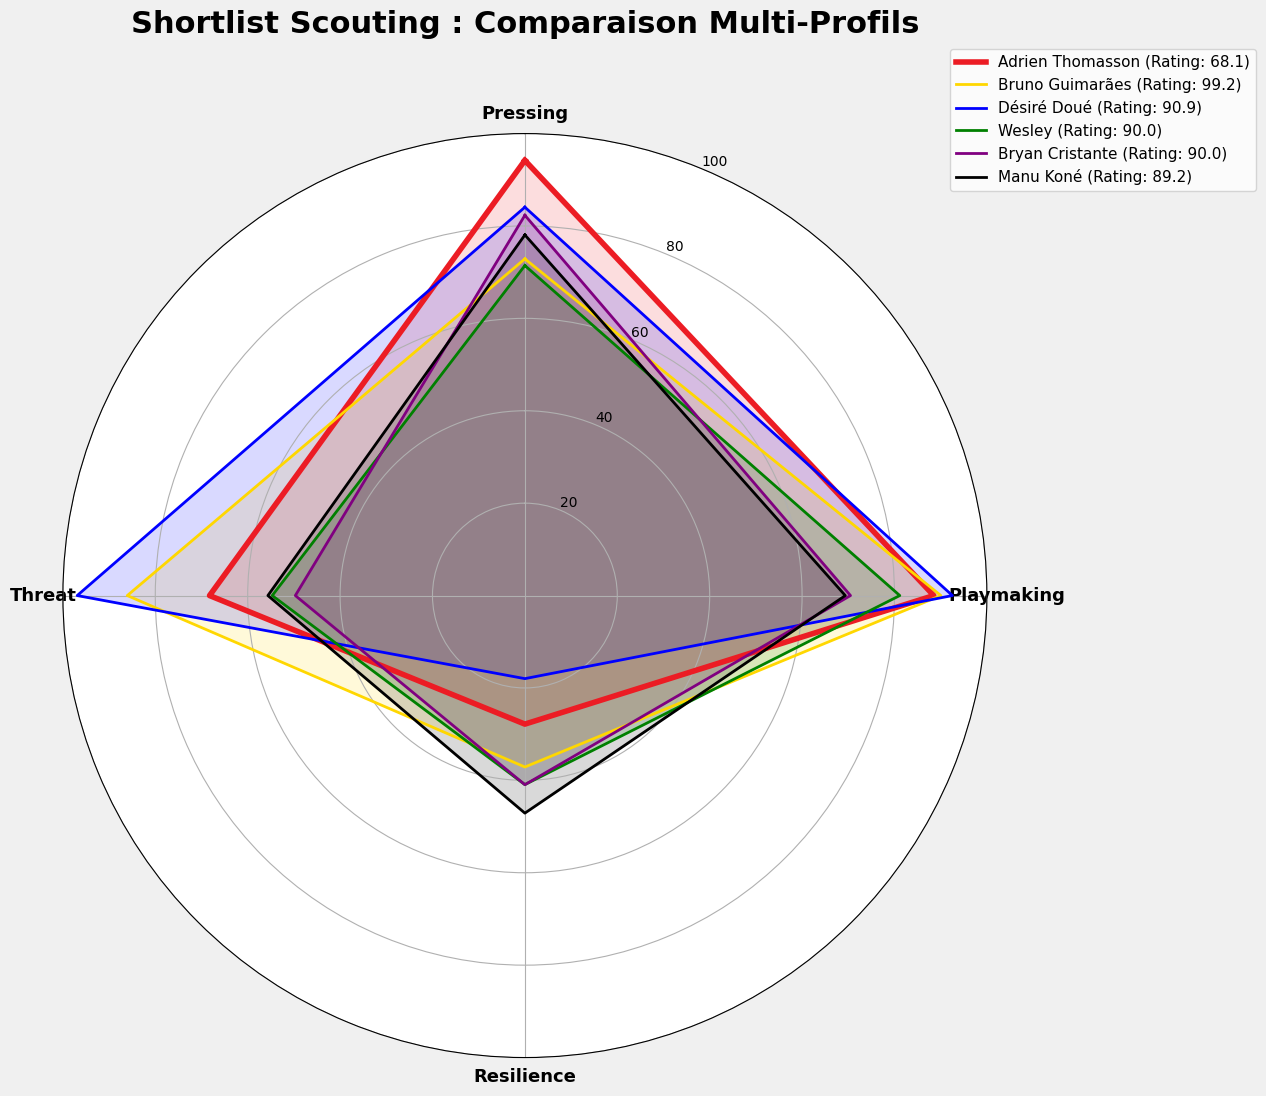

In [311]:

# 1. Sélection de la liste des joueurs à comparer
# On prend Thomasson + les 4 premiers de ta liste top_15_mf
noms_cibles = top_mf_clean['player__name'].head(5).tolist()
tous_les_joueurs = ['Adrien Thomasson'] + noms_cibles

# 2. Configuration des catégories et des couleurs
categories = ['Pressing', 'Playmaking', 'Resilience', 'Threat']
# On définit une palette de couleurs (Rouge pour Thomasson, puis des couleurs variées)
couleurs = ['#EC1C24', '#FFD700', '#0000FF', '#008000', '#800080', "#000000"] 

# 3. Préparation de la structure du Radar
label_loc = np.linspace(start=0, stop=2 * np.pi, num=len(categories), endpoint=False)
label_loc = np.concatenate((label_loc, [label_loc[0]])) # Fermer le cercle

plt.figure(figsize=(12, 12), facecolor='#f0f0f0')
ax = plt.subplot(111, polar=True)

# 4. Boucle pour tracer chaque joueur
for i, nom in enumerate(tous_les_joueurs):
    # On cherche les données dans df_final (qui contient tout le monde)
    df_joueur = df_final[df_final['player__name'] == nom]
    
    if not df_joueur.empty:
        # Extraction des valeurs
        values = df_joueur[['pressing_score', 'playmaking_score', 'resilience_score', 'threat_score']].values.flatten()
        values = np.concatenate((values, [values[0]])) # Fermer le cercle
        
        # Dessin de la ligne
        # On met Thomasson (le premier) avec une ligne plus épaisse
        epaisseur = 4 if i == 0 else 2
        ax.plot(label_loc, values, label=f"{nom} (Rating: {df_joueur['rating_pct'].iloc[0]:.1f})", color=couleurs[i], linewidth=epaisseur)
        
        # Remplissage (plus transparent pour ne pas tout cacher)
        ax.fill(label_loc, values, color=couleurs[i], alpha=0.15)

# 5. Esthétique finale
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(label_loc[:-1]), categories, fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)

plt.title("Shortlist Scouting : Comparaison Multi-Profils", size=22, y=1.1, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11, frameon=True)

plt.show()

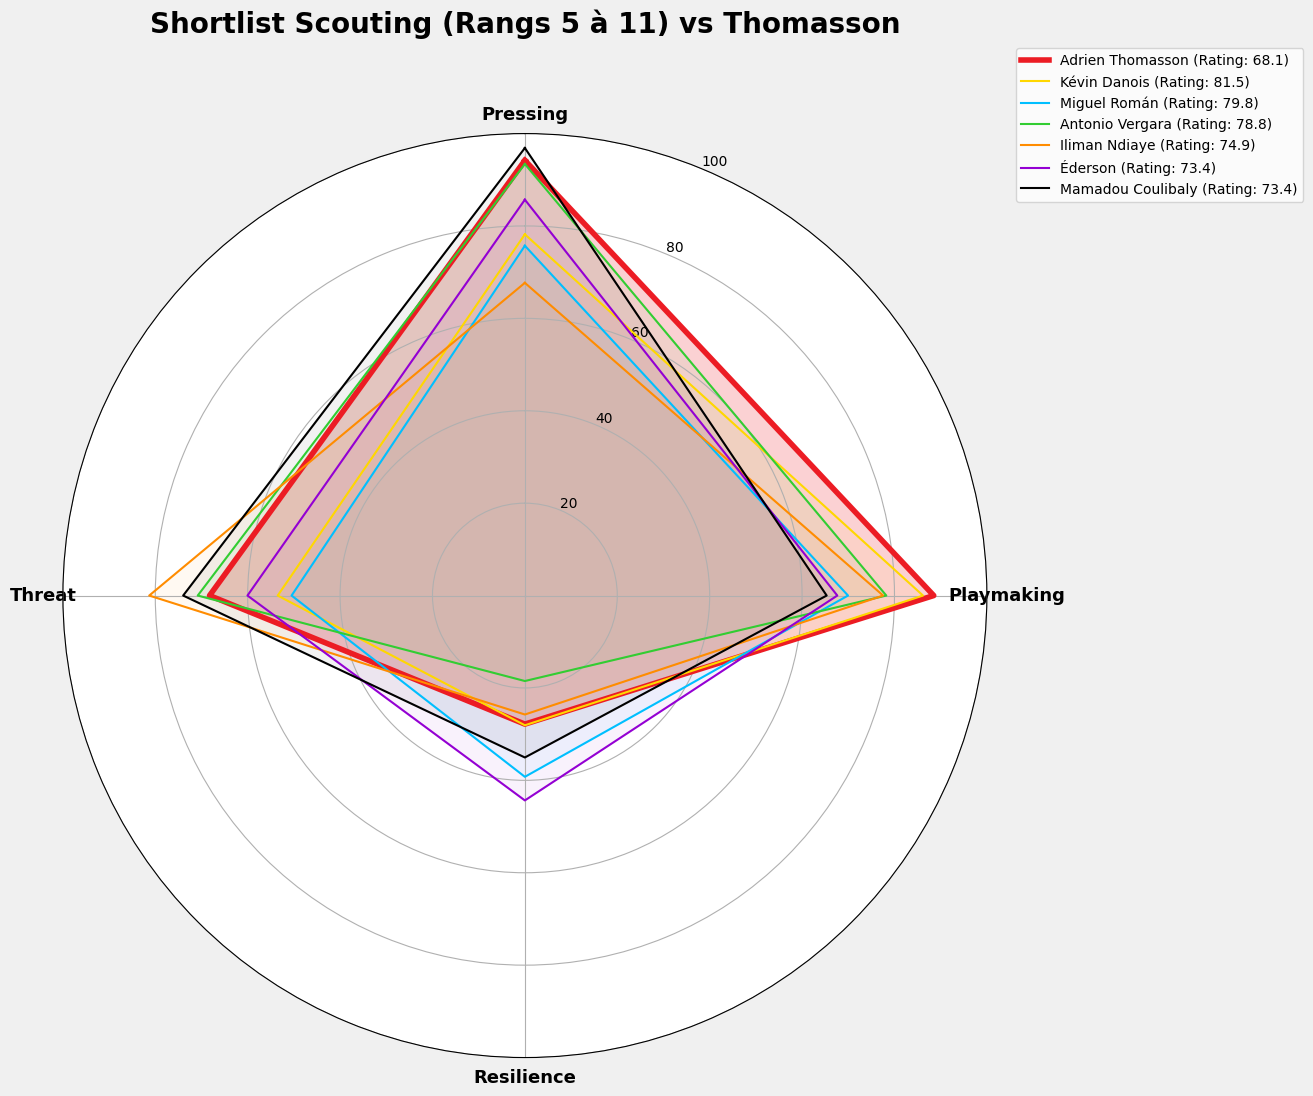

In [312]:
# 1. Sélection des joueurs de la 5ème à la 11ème place
# .iloc[5:11] récupère les index 5, 6, 7, 8, 9 et 10 (le top 5 à 11)
noms_cibles = top_mf_clean['player__name'].iloc[5:11].tolist()
tous_les_joueurs = ['Adrien Thomasson'] + noms_cibles

# 2. Configuration des catégories et des couleurs (7 couleurs nécessaires)
categories = ['Pressing', 'Playmaking', 'Resilience', 'Threat']
# Rouge pour Thomasson, puis 5 couleurs distinctes pour les autres
couleurs = ['#EC1C24', '#FFD700', '#00BFFF', '#32CD32', '#FF8C00', '#9400D3', "#000000"] 

# 3. Préparation de la structure du Radar
label_loc = np.linspace(start=0, stop=2 * np.pi, num=len(categories), endpoint=False)
label_loc = np.concatenate((label_loc, [label_loc[0]])) 

plt.figure(figsize=(12, 12), facecolor='#f0f0f0')
ax = plt.subplot(111, polar=True)

# 4. Boucle pour tracer chaque joueur
for i, nom in enumerate(tous_les_joueurs):
    df_joueur = df_final[df_final['player__name'] == nom]
    
    if not df_joueur.empty:
        # Extraction des valeurs et fermeture du cercle
        values = df_joueur[['pressing_score', 'playmaking_score', 'resilience_score', 'threat_score']].values.flatten()
        values = np.concatenate((values, [values[0]]))
        
        # Style : Thomasson en gras, les autres plus fins
        epaisseur = 4 if nom == 'Adrien Thomasson' else 1.5
        alpha_remplissage = 0.2 if nom == 'Adrien Thomasson' else 0.05
        
        ax.plot(label_loc, values, label=f"{nom} (Rating: {df_joueur['rating_pct'].iloc[0]:.1f})", 
                color=couleurs[i], linewidth=epaisseur)
        ax.fill(label_loc, values, color=couleurs[i], alpha=alpha_remplissage)

# 5. Esthétique finale
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(label_loc[:-1]), categories, fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)

plt.title("Shortlist Scouting (Rangs 5 à 11) vs Thomasson", size=20, y=1.1, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10, frameon=True)

plt.show()

In [313]:
# 1. On définit 8 métriques détaillées pour un champ visuel total
categories_det = [
    'Tackles', 'Interceptions', 'Final 3rd Passes', 'Key Passes', 
    'xA (Danger)', 'xG (Placement)', 'Goals', 'Duels %'
]

# Les colonnes correspondantes dans ton df_final
cols_det = [
    'tackles_p90_pct', 'interceptions_p90_pct', 'accurateFinalThirdPasses_p90_pct', 
    'keyPasses_p90_pct', 'expectedAssists_p90_pct', 'expectedGoals_p90_pct', 
    'goals_p90_pct', 'groundDuelsWonPercentage_pct'
]


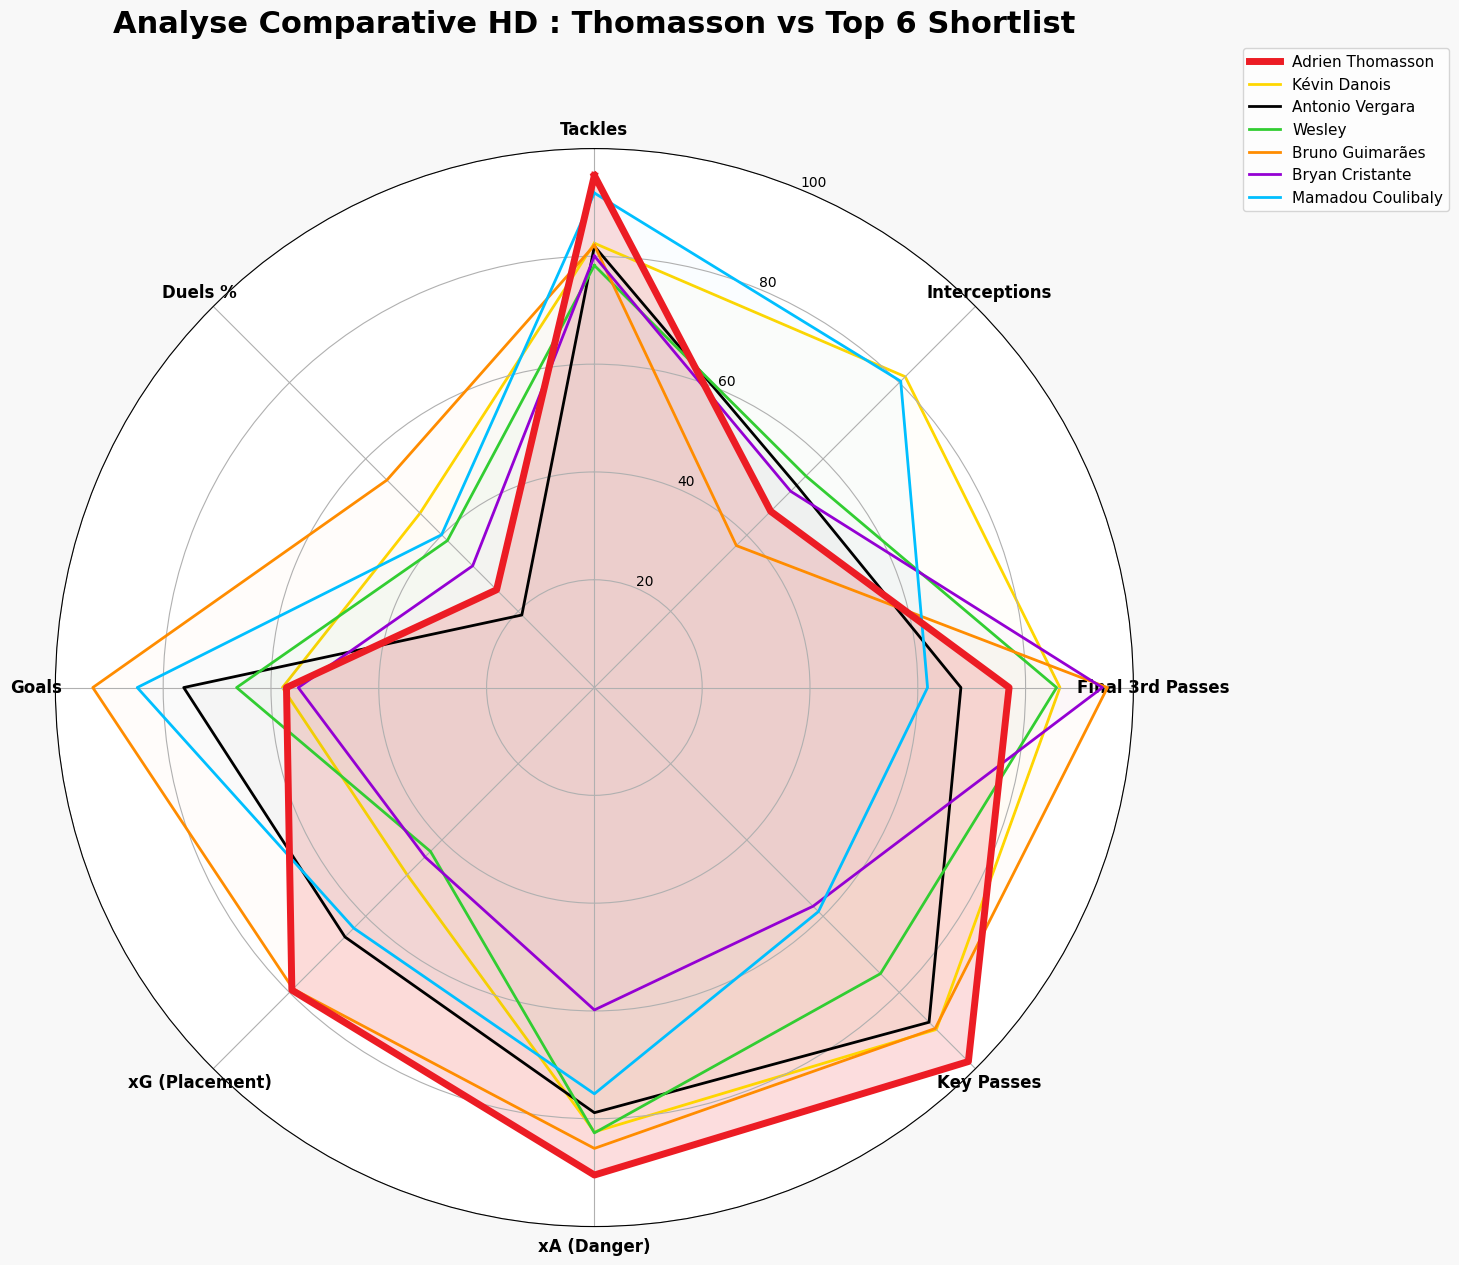

In [314]:
# 1. Ta liste de clones repérés
shortlist_noms = [
    "Kévin Danois", 
    "Antonio Vergara", 
    "Wesley", 
    "Bruno Guimarães", 
    "Bryan Cristante",
    "Mamadou Coulibaly"
       
]


# On ajoute Thomasson à la liste pour la comparaison
tous_les_profils = ['Adrien Thomasson'] + shortlist_noms

# 2. Configuration des 8 axes HD
categories_det = [
    'Tackles', 'Interceptions', 'Final 3rd Passes', 'Key Passes', 
    'xA (Danger)', 'xG (Placement)', 'Goals', 'Duels %'
]
cols_det = [
    'tackles_p90_pct', 'interceptions_p90_pct', 'accurateFinalThirdPasses_p90_pct', 
    'keyPasses_p90_pct', 'expectedAssists_p90_pct', 'expectedGoals_p90_pct', 
    'goals_p90_pct', 'groundDuelsWonPercentage_pct'
]

# Palette : Rouge vif pour Thomasson, puis des couleurs distinctes pour les cibles
couleurs = ['#EC1C24', '#FFD700', '#000000', '#32CD32', '#FF8C00', '#9400D3', "#00BFFF"]

# 3. Préparation du cercle
angles = np.linspace(0, 2*np.pi, len(categories_det), endpoint=False).tolist()
angles += angles[:1] # Fermeture du cercle

plt.figure(figsize=(14, 14), facecolor='#f8f8f8')
ax = plt.subplot(111, polar=True)

# 4. Boucle de traçage automatique
for i, nom in enumerate(tous_les_profils):
    # Extraction des données
    if nom == 'Adrien Thomasson':
        df_j = df_final[df_final['player__name'].str.contains('Thomasson', na=False)]
    else:
        df_j = df_final[df_final['player__name'] == nom]
    
    if not df_j.empty:
        values = df_j[cols_det].values.flatten().tolist()
        values += values[:1] # Fermeture des données
        
        # Style : Thomasson est la référence (plus épais, au premier plan)
        is_ref = (nom == 'Adrien Thomasson')
        lw = 5 if is_ref else 2
        z = 10 if is_ref else i
        alpha_fill = 0.15 if is_ref else 0.02 # Remplissage très léger pour les clones
        
        ax.plot(angles, values, color=couleurs[i], linewidth=lw, label=nom, zorder=z)
        ax.fill(angles, values, color=couleurs[i], alpha=alpha_fill)

# 5. Esthétique et "Champ Visuel"
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), categories_det, fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)

plt.title("Analyse Comparative HD : Thomasson vs Top 6 Shortlist", size=22, y=1.1, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11, frameon=True)

plt.show()

**Note :** Cette analyse se base sur la comparaison des 8 axes (Tacles, Interceptions, Passes 3ème tiers, Key Passes, xA, xG, Goals, % Duels)
**Analyse**:
Le radar met en lumière trois approches distinctes pour succéder à Adrien Thomasson :

1. **Le Mimétisme Élite (Bruno Guimarães) :** Sa courbe épouse presque parfaitement celle de Thomasson sur les axes de volume (Tackles, Interceptions, Passes 3ème tiers). Sa supériorité sur les Duels % montre qu'il est une version "augmentée" du profil initial. C'est le remplaçant miroir.

2. **La Créativité Pure (Antonio Vergara) :** On observe une pointe saillante sur l'axe Final 3rd Passes et Key Passes. Vergara ne se contente pas de compenser le départ de Thomasson ; il fait évoluer le rôle vers un profil de "meneur de jeu reculé" plus technique.

3. **Le Potentiel Contextuel (Kévin Danois) :** Si sa surface sur le radar semble plus rétractée sur les axes xA et xG, l'analyse des Interceptions et des Final 3rd Passes montre une activité débordante. Son retrait statistique sur la finition est le reflet direct du contexte de l'AJ Auxerre (17 buts en 23 matchs) et non d'une carence technique.

**Conclusion :** Le radar valide la pertinence du "Thomasson Engine". Nous n'avons pas seulement trouvé des joueurs avec un bon score, mais des joueurs qui occupent l'espace de la même manière tactique.

## Conclusion

### Pourquoi le profil "Thomasson" est vital pour Sage à Lens?
Sous Pierre Sage, le RC Lens pratique un football de transition intelligente. Thomasson est la pièce maîtresse de cet équilibre : il compense les déplacements de ses partenaires et assure la première passe de rupture. Pour maintenir la 2ème place, le club doit recruter un joueur capable de résister à la pression tout en conservant un volume défensif d'élite.

### Synthèse de la Méthodologie
Ce projet a permis de traiter une base de 1 600 joueurs à travers un entonnoir de sélection rigoureux :

1. Filtre Poste : 987 milieux identifiés.

2. Filtre ADN (Similarité > 98%) : 78 "clones" tactiques isolés.

3. Filtre Performance (Rating > 65% & < 30 ans) : 17 candidats d'élite.

### La Recommandation Prioritaire : Kévin Danois (AJ Auxerre)
| Rang | Joueur | Âge | Club | Valeur | Statut | Profil Stratégique |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 🥇 **1er** | **Kévin Danois** | 21 ans | AJ Auxerre | 10,00 M€ | Cible Idéale | **La Pépite** : Gros potentiel, stats à pondérer par le contexte d'Auxerre et Investissement "Signature" du club. |
| 🥈 **2e** | **Antonio Vergara** | 23 ans | SSC Napoli | 2,50 M€ | Opportunité | **Le Technicien** : Fluidité technique et intelligence tactique/bas coût. |
| 🥉 **3e** | **Bruno Guimarães** | 28 ans | Newcastle | 75,00 M€ | Hors Budget | **Le Leader** : Expérience, leadership et volume de jeu élite mais inaccessible. |


### Analyse de Cohérence Budgétaire
L'analyse de l'historique des transferts du club montre une stratégie claire : **Acheter à forte plus-value potentielle.**
* L'exception 23/24 : Le club a consenti des efforts massifs pour Elye Wahi ($30,00\text{ M€}$) et Andy Diouf ($14,00\text{ M€}$).
* La réalité standard (24/25 & 25/26) : Le club privilégie désormais des profils entre $5,00\text{ M€}$ et $8,00\text{ M€}$ (Zaroury, Baidoo, Sangaré), générant des résultats nets positifs impressionnants ($+72,04\text{ M€}$ en 24/25 et $+45,60\text{ M€}$ en 25/26).

### **Pourquoi Bruno Guimarães est écarté ?**
Bien qu'il soit le "clone parfait" statistiquement, sa valeur de $75,00\text{ M€}$ représente plus de la totalité du budget de revenus de la saison dernière. Son recrutement briserait le modèle économique du club.

### Synthèse du Profil Recherché
L'objectif était de trouver un successeur à Adrien Thomasson, capable de s'intégrer immédiatement dans le système de Pierre Sage. Le profil exigeait un équilibre rare entre :

* Intensité défensive (Pressing Index élevé).

* Qualité de connexion technique (Playmaking & Passes dans le dernier tiers).

* Intelligence de jeu pour maintenir Lens à la lutte pour le titre (2ème de L1).

### Pourquoi Kévin Danois est le choix n°1 ?
À $10,00\text{ M€}$, Danois se situe exactement dans la "tranche supérieure" de l'investissement lensois (proche des $14,00\text{ M€}$ d'un Andy Diouf).
* Viabilité financière : Le club dispose d'un résultat total de $+45,60\text{ M€}$ cette saison ; l'achat de Danois est donc totalement autofinancé.
* Potentiel de revente : À 21 ans, son profil de "milieu total" formé à Auxerre peut suivre la trajectoire d'un Loïs Openda (acheté $15,39\text{ M€}$, revendu bien plus cher).
* Ajustement Data : Ses statistiques de xG/xA bridées par le contexte auxerrois (17 buts marqués) en font une opportunité de marché. Sa valeur réelle explosera une fois intégré au système dominant de Pierre Sage.

### Verdict Final

Le "Thomasson Engine" désigne Kévin Danois comme le successeur logique. Il incarne l'équilibre parfait entre l'exigence tactique de Pierre Sage et la rigueur budgétaire du RC Lens. C'est un recrutement à "risque maîtrisé" qui respecte l'ADN du club : détecter le talent avant qu'il ne devienne inaccessible.